In [15]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower

np.random.seed(42)

In [16]:
df = pd.read_csv("anorexia.csv")
print(df.head())
print(df.shape)
print(df.describe())
print(df.info())

   rownames Treat  Prewt  Postwt
0         1  Cont   80.7    80.2
1         2  Cont   89.4    80.1
2         3  Cont   91.8    86.4
3         4  Cont   74.0    86.3
4         5  Cont   78.1    76.1
(72, 4)
       rownames      Prewt      Postwt
count  72.00000  72.000000   72.000000
mean   36.50000  82.408333   85.172222
std    20.92845   5.182466    8.035173
min     1.00000  70.000000   71.300000
25%    18.75000  79.600000   79.325000
50%    36.50000  82.300000   84.050000
75%    54.25000  86.000000   91.550000
max    72.00000  94.900000  103.600000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rownames  72 non-null     int64  
 1   Treat     72 non-null     object 
 2   Prewt     72 non-null     float64
 3   Postwt    72 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 2.4+ KB
None


In [17]:
post = np.array(df.iloc[:, 3])
pre = np.array(df.iloc[:, 2])
treat = np.array(df.iloc[:, 1])
print(post)
print(pre)
print(treat)

[ 80.2  80.1  86.4  86.3  76.1  78.1  75.1  86.7  73.5  84.6  77.4  79.5
  89.6  81.4  81.8  77.3  84.2  75.4  79.5  73.   88.3  84.7  81.4  81.2
  88.2  78.8  82.2  85.6  81.4  81.9  76.4 103.6  98.4  93.4  73.4  82.1
  96.7  95.3  82.4  72.5  90.9  71.3  85.4  81.6  89.1  83.9  82.7  75.7
  82.6 100.4  85.2  83.6  84.6  96.2  86.7  95.2  94.3  91.5  91.9 100.3
  76.7  76.8 101.6  94.9  75.2  77.8  95.5  90.7  92.5  93.8  91.7  98. ]
[80.7 89.4 91.8 74.  78.1 88.3 87.3 75.1 80.6 78.4 77.6 88.7 81.3 78.1
 70.5 77.3 85.2 86.  84.1 79.7 85.5 84.4 79.6 77.5 72.3 89.  80.5 84.9
 81.5 82.6 79.9 88.7 94.9 76.3 81.  80.5 85.  89.2 81.3 76.5 70.  80.4
 83.3 83.  87.7 84.2 86.4 76.5 80.2 87.8 83.3 79.7 84.5 80.8 87.4 83.8
 83.3 86.  82.5 86.7 79.6 76.9 94.2 73.4 80.5 81.6 82.1 77.6 83.5 89.9
 86.  87.3]
['Cont' 'Cont' 'Cont' 'Cont' 'Cont' 'Cont' 'Cont' 'Cont' 'Cont' 'Cont'
 'Cont' 'Cont' 'Cont' 'Cont' 'Cont' 'Cont' 'Cont' 'Cont' 'Cont' 'Cont'
 'Cont' 'Cont' 'Cont' 'Cont' 'Cont' 'Cont' 'CBT' 'CB

--- NORMALITY CHECK (Shapiro-Wilk) ---

Variable: pre
  Treatment: CBT | W-Statistic: 0.9699, p-value: 0.5580
  Treatment: Cont | W-Statistic: 0.9687, p-value: 0.5895
  Treatment: FT | W-Statistic: 0.9882, p-value: 0.9972

Variable: post
  Treatment: CBT | W-Statistic: 0.9520, p-value: 0.2057
  Treatment: Cont | W-Statistic: 0.9668, p-value: 0.5431
  Treatment: FT | W-Statistic: 0.8393, p-value: 0.0074


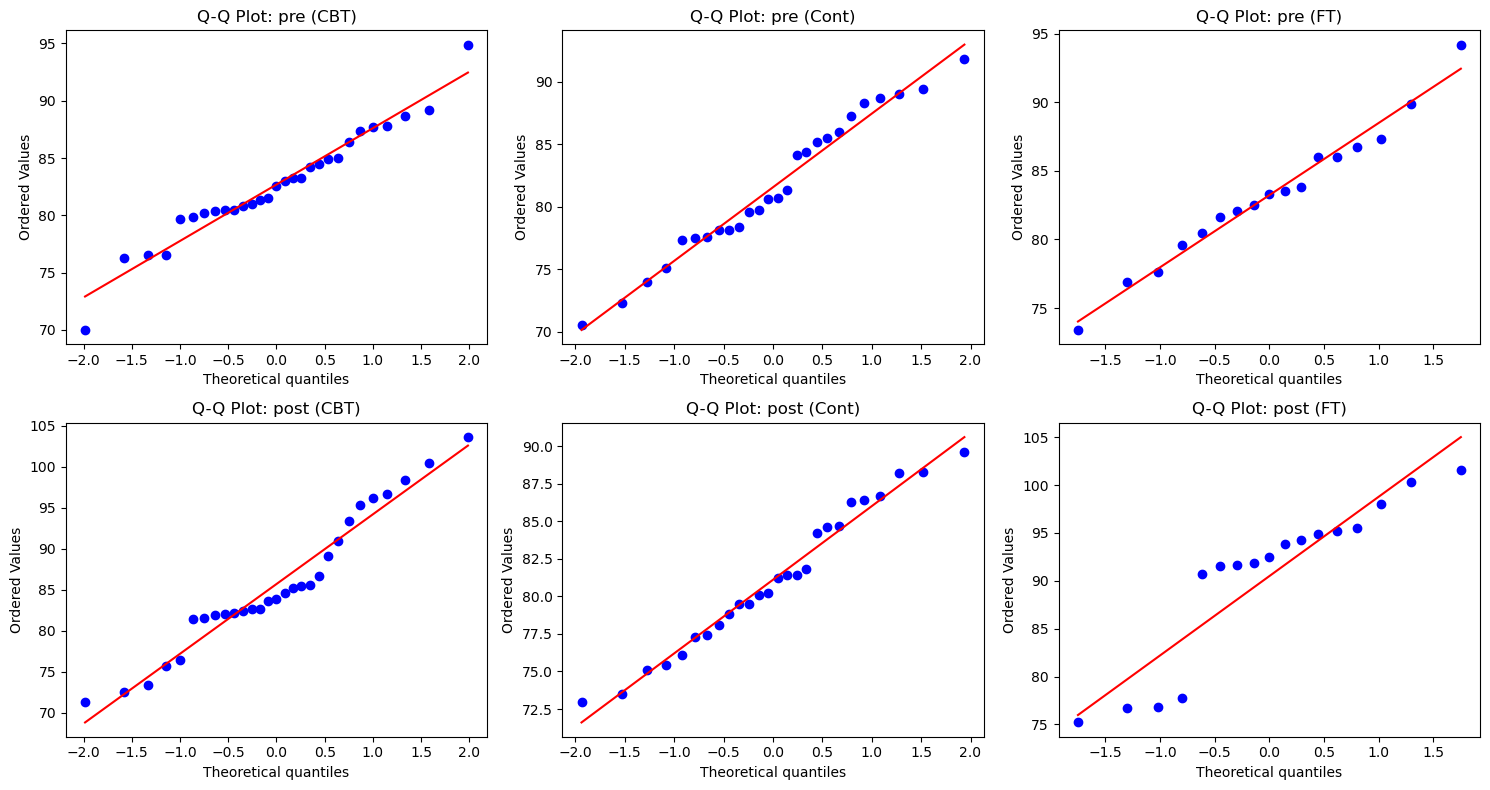


--- EQUAL VARIANCE CHECK (Levene's Test) ---
Variable: pre  | Levene Statistic: 0.9366, p-value: 0.3969
Variable: post | Levene Statistic: 1.7671, p-value: 0.1785


In [ ]:
unique_treatments = np.unique(treat)

print("\nVariable: pre")
for trt in unique_treatments:
    group_pre = pre[treat == trt]
    stat, p_value = stats.shapiro(group_pre)
    print(f"  Treatment: {trt} | W-Statistic: {stat:.4f}, p-value: {p_value:.4f}")

print("\nVariable: post")
for trt in unique_treatments:
    group_post = post[treat == trt]
    stat, p_value = stats.shapiro(group_post)
    print(f"  Treatment: {trt} | W-Statistic: {stat:.4f}, p-value: {p_value:.4f}")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for j, trt in enumerate(unique_treatments):
    stats.probplot(pre[treat == trt], dist="norm", plot=axes[0, j])
    axes[0, j].set_title(f"Q-Q Plot: pre ({trt})")
    stats.probplot(post[treat == trt], dist="norm", plot=axes[1, j])
    axes[1, j].set_title(f"Q-Q Plot: post ({trt})")
plt.tight_layout()
plt.show()

pre_groups = [pre[treat == trt] for trt in unique_treatments]
stat, p_value = stats.levene(*pre_groups)
print(f"Variable: pre  | Levene Statistic: {stat:.4f}, p-value: {p_value:.4f}")

post_groups = [post[treat == trt] for trt in unique_treatments]
stat, p_value = stats.levene(*post_groups)
print(f"Variable: post | Levene Statistic: {stat:.4f}, p-value: {p_value:.4f}")

all the results including test for each treatment's pre and post values shows that each observation satisfies requirements of the null hypothesis exept Family Therapy. Family therapy's p-value is below threshold and as we can see from graphs, treatment has effect on this specific treatment group 

since FT group violated the normality assumption, we will use the non-parametric Wilcoxon Signed-Rank Test for that group. For the CBT and Cont groups, which passed the normality checks, we will use the standard parametric Paired t-test.

In [25]:
ft_pre = pre[treat == 'FT']
ft_post = post[treat == 'FT']

stat_w, p_w = stats.wilcoxon(ft_pre, ft_post)

z_score = stats.norm.ppf(1 - p_w/2)
effect_size_r = z_score / np.sqrt(len(ft_pre) * 2)

print(f"Test Statistic: {stat_w:.4f}")
print(f"p-value: {p_w:.4f}")
print(f"Effect Size (r): {effect_size_r:.4f}")
if p_w < 0.05:
    print("Conclusion: Family Therapy resulted in a statistically significant change in body weight.\n")
else:
    print("Conclusion: Family Therapy did not result in a statistically significant change in body weight.\n")

cbt_pre = pre[treat == 'CBT']
cont_pre = pre[treat == 'Cont']

stat_f, p_f = stats.f_oneway(cbt_pre, cont_pre, ft_pre)

grand_mean = np.mean(pre)
ss_total = np.sum((pre - grand_mean)**2)
ss_between = (len(cbt_pre) * (np.mean(cbt_pre) - grand_mean)**2 +
              len(cont_pre) * (np.mean(cont_pre) - grand_mean)**2 +
              len(ft_pre) * (np.mean(ft_pre) - grand_mean)**2)
eta_squared = ss_between / ss_total

print(f"Test Statistic (F): {stat_f:.4f}")
print(f"p-value: {p_f:.4f}")
print(f"Effect Size (Eta-squared): {eta_squared:.4f}")
if p_f < 0.05:
    print("Conclusion: There was a significant difference in baseline weights across the treatment groups prior to intervention.\n")
else:
    print("Conclusion: There was no significant difference in baseline weights across the groups; they started on equal footing.\n")

cbt_change = post[treat == 'CBT'] - pre[treat == 'CBT']
cont_change = post[treat == 'Cont'] - pre[treat == 'Cont']

stat_t, p_t = stats.ttest_ind(cbt_change, cont_change)

nx, ny = len(cbt_change), len(cont_change)
dof = nx + ny - 2
pool_var = ((nx - 1) * np.var(cbt_change, ddof=1) + (ny - 1) * np.var(cont_change, ddof=1)) / dof
cohens_d = (np.mean(cbt_change) - np.mean(cont_change)) / np.sqrt(pool_var)

print(f"Test Statistic (t): {stat_t:.4f}")
print(f"p-value: {p_t:.4f}")
print(f"Effect Size (Cohen's d): {cohens_d:.4f}")
if p_t < 0.05:
    print("Conclusion: CBT produced a significantly different change in weight compared to the Control group.\n")
else:
    print("Conclusion: There was no significant difference in the amount of weight changed between patients receiving CBT and patients in the Control group.\n")

Test Statistic: 11.0000
p-value: 0.0008
Effect Size (r): 0.5727
Conclusion: Family Therapy resulted in a statistically significant change in body weight.

Test Statistic (F): 0.5995
p-value: 0.5519
Effect Size (Eta-squared): 0.0171
Conclusion: There was no significant difference in baseline weights across the groups; they started on equal footing.

Test Statistic (t): 1.6760
p-value: 0.0996
Effect Size (Cohen's d): 0.4527
Conclusion: There was no significant difference in the amount of weight changed between patients receiving CBT and patients in the Control group.



**question 1:**


null hypothesis: The median difference between pre-treatment and post-treatment weights in the Family Therapy (FT) group is zero

alternative hypothesis: The median difference between pre-treatment and post-treatment weights in the FT group is not zero

justification: Wilcoxon Signed-Rank Test. We are comparing paired data (pre and post values). We use this test because our first tests revealed that the post-treatment weights for the FT group violate the assumption of normality.

results(from codes output):


Test Statistic: 11.0000


p-value: 0.0008


Effect Size (r): 0.5727


Conclusion: Family Therapy resulted in a statistically significant change in body weight.


**question 2:**


null hypothesis: There is no difference in the mean pre-treatment weights across the CBT, Control (Cont), and FT groups.

alternative hypothesis: At least one treatment group has a significantly different mean pre-treatment weight compared to the others.

justification: One-Way ANOVA. We are comparing the means of three independent, categorical groups. Our assumption checks confirmed that the pre-treatment weights are normally distributed and have equal variances across all three groups, fulfilling the requirements for a parametric ANOVA.

results:
Test Statistic (F): 0.5995


p-value: 0.5519


Effect Size (Eta-squared): 0.0171


Conclusion: There was no significant difference in baseline weights across the groups; they started on equal footing.


**question 3:**


null hypothesis: There is no significant difference in the mean weight change (post-treatment minus pre-treatment) between the CBT and Control groups

alternative hypothesis: There is a significant difference in the mean weight change between the CBT and Control groups

justification: Independent Samples t-test. We are comparing the continuous weight change scores between two independent groups. Since the baseline and post-treatment data for these specific groups passed normality and variance checks, it is standard to use a parametric test to compare their mean differences

results:


Test Statistic (t): 1.6760


p-value: 0.0996


Effect Size (Cohen's d): 0.4527


Conclusion: There was no significant difference in the amount of weight changed between patients receiving CBT and patients in the Control group.

CBT Weight Change 95% CI: 3.01 lbs [0.23, 5.79]
Control Weight Change 95% CI: -0.45 lbs [-3.68, 2.78]


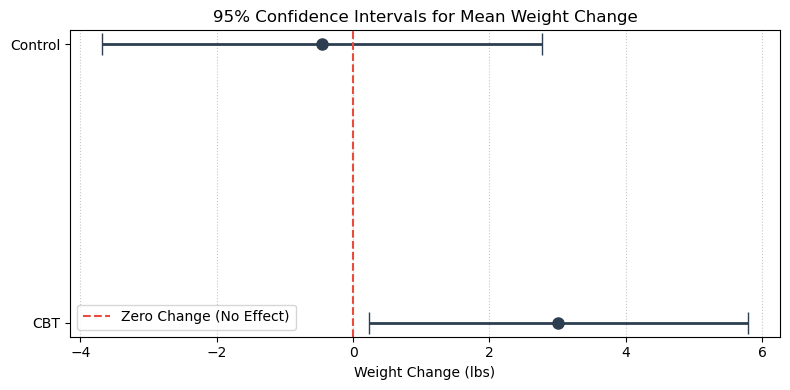

In [26]:
cbt_change = post[treat == 'CBT'] - pre[treat == 'CBT']
cont_change = post[treat == 'Cont'] - pre[treat == 'Cont']

def get_95_ci(data):
    n = len(data)
    mean = np.mean(data)
    sem = stats.sem(data) 
    t_crit = stats.t.ppf(0.975, n - 1) 
    margin = t_crit * sem
    return mean, mean - margin, mean + margin

cbt_mean, cbt_low, cbt_high = get_95_ci(cbt_change)
cont_mean, cont_low, cont_high = get_95_ci(cont_change)

print(f"CBT Weight Change 95% CI: {cbt_mean:.2f} lbs [{cbt_low:.2f}, {cbt_high:.2f}]")
print(f"Control Weight Change 95% CI: {cont_mean:.2f} lbs [{cont_low:.2f}, {cont_high:.2f}]")

means = [cbt_mean, cont_mean]
errors = [[cbt_mean - cbt_low, cont_mean - cont_low], 
          [cbt_high - cbt_mean, cont_high - cont_mean]]

plt.figure(figsize=(8, 4))
plt.errorbar(means, ['CBT', 'Control'], xerr=errors, fmt='o', color='#2c3e50', 
             capsize=8, markersize=8, linewidth=2)

plt.axvline(x=0, color='#e74c3c', linestyle='--', label='Zero Change (No Effect)')

plt.title('95% Confidence Intervals for Mean Weight Change')
plt.xlabel('Weight Change (lbs)')
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

the plot says us that, we are 95% confident that, for CBT group, weight change mean is in interval of  [0.23, 5.79] and for control group weight change mean is in interval of [-3.68, 2.78]

as we can see from the plots, 0 stays outside the boundaries of the CBT group, so that means treatment has significant effect(p-value<0.05) on CBT group. That is why, we can reject null hypothesis.

on the other hand, in control group, 0 stays inside the boundaries and that means the can be zero change in the weight of the control group. so we fail to reject the null hypothesis

In [27]:
import statsmodels.stats.power as smp

nx = len(cbt_change)
ny = len(cont_change)

mean_diff = np.mean(cbt_change) - np.mean(cont_change)
dof = nx + ny - 2
pool_var = ((nx - 1) * np.var(cbt_change, ddof=1) + (ny - 1) * np.var(cont_change, ddof=1)) / dof
cohens_d = abs(mean_diff / np.sqrt(pool_var))

power_analysis = smp.TTestIndPower()

current_power = power_analysis.power(effect_size=cohens_d, nobs1=nx, ratio=ny/nx, alpha=0.05)

print("--- POST-HOC POWER ANALYSIS ---")
print(f"Observed Effect Size (Cohen's d): {cohens_d:.4f}")
print(f"Current Sample Sizes: CBT = {nx}, Control = {ny}")
print(f"Current Statistical Power: {current_power:.4f} (or {current_power*100:.2f}%)\n")

required_n = power_analysis.solve_power(effect_size=cohens_d, power=0.80, alpha=0.05, ratio=1.0)

print("--- REQUIRED SAMPLE SIZE ---")
print(f"To achieve 80% power at alpha = 0.05:")
print(f"You need roughly {np.ceil(required_n):.0f} patients PER GROUP.")
print(f"Total required sample size: {np.ceil(required_n) * 2:.0f} patients.")

--- POST-HOC POWER ANALYSIS ---
Observed Effect Size (Cohen's d): 0.4527
Current Sample Sizes: CBT = 29, Control = 26
Current Statistical Power: 0.3768 (or 37.68%)

--- REQUIRED SAMPLE SIZE ---
To achieve 80% power at alpha = 0.05:
You need roughly 78 patients PER GROUP.
Total required sample size: 156 patients.


**our power test outputs are:**

--- POST-HOC POWER ANALYSIS ---


Observed Effect Size (Cohen's d): 0.4527


Current Sample Sizes: CBT = 29, Control = 26


Current Statistical Power: 0.3768 (or 37.68%)


--- REQUIRED SAMPLE SIZE ---


To achieve 80% power at alpha = 0.05:
You need roughly 78 patients PER GROUP.
Total required sample size: 156 patients.

=============================================================================

so, our dataset does not provide sufficient power. our tests will likely have type II error(false negative).


it means that, previous test's conclusion (which is, "There is no significant difference in the amount of weight changed between CBT and the Control group") is not fully reliable, because, to get this conclusion more correctly, we need 156 patients and our sample size is so small.

***TASK 5***


We evaluated clinical data to determine best treatment for patients who diagnosed with anorexia. We compared 3 groups independently(CBT, FT, Control) to get the best results. Main business question in here is, which treatment has better effect? On which treatment we invest more?


Before any treatments began, we verified that patients in all three groups started at comparable baseline weights, ensuring a fair and balanced starting point for our analysis. Following the treatment period, our evaluation revealed important opinion about efficieny of treatments. Family Therapy treatment came up with best results. Patients in this group experienced a clear, consistent increase in weight.


For CBT group, our observations are:


When we just look these patients receiving this therapy, we will see significant gain on weight. So we can say this treatment has significant effect, right? Actually, no! When we compare these results with Control groups', we can see that, although inclusive results are shown that treatment is effective, it is not, because there is no significant difference between CBT and Control groups weight changes. So, weight gainage of CBT is mostly natural, treatment has no significant effect.


The main problem is that this study only looked at a very small number of people. Because the groups were so small, we cannot safely say that CBT does not work. We simply do not have enough data yet to prove it works better than standard care.


Therefore, we recommend making Family Therapy our main treatment choice right now, as the results are clear and positive. We should not stop using CBT just yet. Instead, we need to study a much larger group of patients to make a final, confident decision on whether to keep it in our program.